In [1]:
pip install -U peft


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 8.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.5 MB/s eta 0:00:00:00:0100:01
  Attempting uni

# Finetuning the model

In [1]:
# Cell 1: install dependencies
!pip install -q accelerate==0.22.0 transformers==4.35.0 diffusers[training]==0.19.0 datasets safetensors xformers==0.0.20 bitsandbytes
# xformers optional — helps memory if available on Kaggle; if it fails to install, that's okay.

# Download the LoRA training script from diffusers examples
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py -O /kaggle/working/train_text_to_image_lora.py

# show python version and GPU
!python -V
!nvidia-smi || true


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.5/960.5 kB 30.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.2/251.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 94.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.1/109.1 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 110.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 55.2 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 39.8 MB/s eta 0:00:00
 

In [18]:
!git clone https://github.com/huggingface/diffusers.git


Cloning into 'diffusers'...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


remote: Enumerating objects: 102993, done.
remote: Counting objects: 100% (646/646), done.
remote: Compressing objects: 100% (357/357), done.
remote: Total 102993 (delta 509), reused 289 (delta 285), pack-reused 102347 (from 3)
Receiving objects: 100% (102993/102993), 77.63 MiB | 32.32 MiB/s, done.
Resolving deltas: 100% (75896/75896), done.


In [1]:
# ---------------- Clone diffusers repo ----------------
!git clone https://github.com/huggingface/diffusers.git

# ---------------- Imports ----------------
import os
from pathlib import Path
from PIL import Image
import json
import shutil

# ---------------- Paths ----------------
INSTANCE_DIR = "/kaggle/input/pedestals-dataset/pedestals"  # Your uploaded images
DATASET_DIR = "./pedestals_dataset"

os.makedirs(DATASET_DIR, exist_ok=True)

# ---------------- Create ImageFolder style dataset ----------------
images_dir = Path(DATASET_DIR) / "images"
images_dir.mkdir(exist_ok=True)

images_dir.mkdir(exist_ok = True)

# Copy images and rename sequentially
for idx, file in enumerate(sorted(Path(INSTANCE_DIR).glob("*"))):
    img = Image.open(file)
    img.save(images_dir / f"{idx:04d}.png")
    img.close()

# ---------------- Create captions.json ----------------
captions = [{"image": f"{idx:04d}.png", "text": "pedestal"} for idx in range(len(list(images_dir.iterdir())))]

with open(Path(DATASET_DIR) / "captions.json", "w") as f:
    json.dump(captions, f, indent=4)

print("Dataset prepared:", DATASET_DIR)


Cloning into 'diffusers'...
remote: Enumerating objects: 102993, done.
remote: Counting objects: 100% (630/630), done.
remote: Compressing objects: 100% (342/342), done.
remote: Total 102993 (delta 509), reused 288 (delta 288), pack-reused 102363 (from 4)
Receiving objects: 100% (102993/102993), 77.63 MiB | 28.76 MiB/s, done.
Resolving deltas: 100% (75897/75897), done.
Dataset prepared: ./pedestals_dataset


In [ ]:
!pip install -U diffusers==0.26.0 transformers accelerate bitsandbytes safetensors


In [1]:
!accelerate launch /kaggle/working/diffusers/examples/research_projects/lora/train_text_to_image_lora.py \
    --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
    --train_text_encoder \
    --train_data_dir="./pedestals_dataset/images" \
    --resolution=512 \
    --train_batch_size=2 \
    --max_train_steps=1000 \
    --learning_rate=1e-4 \
    --output_dir="./lora-pedestal-auto" \
    --mixed_precision="fp16" \
    --logging_dir="./logs" \
    --checkpointing_steps=200


/usr/bin/python3: can't open file '/kaggle/working/diffusers/examples/research_projects/lora/train_text_to_image_lora.py': [Errno 2] No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/accelerate", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/accelerate/commands/accelerate_cli.py", line 50, in main
    args.func(args)
  File "/usr/local/lib/python3.11/dist-packages/accelerate/commands/launch.py", line 1199, in launch_command
    simple_launcher(args)
  File "/usr/local/lib/python3.11/dist-packages/accelerate/commands/launch.py", line 785, in simple_launcher
    raise subprocess.CalledProcessError(returncode=process.returncode, cmd=cmd)
subprocess.CalledProcessError: Command '['/usr/bin/python3', '/kaggle/working/diffusers/examples/research_projects/lora/train_text_to_image_lora.py', '--pretrained_model_name_or_path=runwayml/stable-diffusion-v1-5', '--train_text_encoder', '--train_data_dir=.

# Using finetuned model

In [2]:
pip install --upgrade diffusers huggingface-hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 18.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 29.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.33.1
    Uninstalling huggingface-hub-0.33.1:
      Successfully uninstalled huggingface-hub-0.33.1
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.27.2
    Uninstalling diffusers-0.27.2:
      Successfully uninstalled diffusers-0.27.2
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Cell 1: install dependencies
!pip install -q accelerate==0.22.0 transformers==4.35.0 diffusers[training]==0.19.0 datasets safetensors xformers==0.0.20 bitsandbytes
# xformers optional — helps memory if available on Kaggle; if it fails to install, that's okay.

# Download the LoRA training script from diffusers examples
!wget -q https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py -O /kaggle/working/train_text_to_image_lora.py

# show python version and GPU
!python -V
!nvidia-smi || true


# Modified Bg

In [ ]:
#F1

# ===============================
# 1. Install dependencies
# ===============================
!pip install -q diffusers==0.27.2 transformers accelerate peft safetensors datasets bitsandbytes

# ===============================
# 2. Imports
# ===============================
import torch
from diffusers import StableDiffusionPipeline

# ===============================
# 3. Hugging Face Login
# ===============================
# You need a Hugging Face token to download the base Stable Diffusion model
# Create one at https://huggingface.co/settings/tokens
from huggingface_hub import login
login()   # paste your token here when prompted

# ===============================
# 4. Paths
# ===============================
pretrained_model = "runwayml/stable-diffusion-v1-5"

# If you uploaded your dataset as a Kaggle dataset, mount it like this:
train_dir = "/kaggle/input/your-dataset-folder"   # replace with your dataset path
output_dir = "/kaggle/working/lora-style"

# ===============================
# 5. Download training script
# ===============================
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py -O train_text_to_image_lora.py

# ===============================
# 6. Train LoRA (no captions)
# ===============================
!accelerate launch train_text_to_image_lora.py \
  --pretrained_model_name_or_path=$pretrained_model \
  --train_data_dir=$train_dir \
  --resolution=512 \
  --train_batch_size=2 \
  --num_train_epochs=10 \
  --checkpointing_steps=500 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --mixed_precision="fp16" \
  --output_dir=$output_dir \
  --caption_column=None \
  --validation_prompt="a painting in my style" \
  --report_to="tensorboard"

# ===============================
# 7. Load and Test Your LoRA
# ===============================
pipe = StableDiffusionPipeline.from_pretrained(
    pretrained_model,
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights(output_dir)

prompt = "a portrait of a woman in my style"
image = pipe(prompt).images[0]
image.save("/kaggle/working/styled_output.png")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


=== Starting Ad Background Generation ===
Product Data: {'gender': 'women', 'baseColour': 'silver', 'usage': 'casual', 'subCategory': 'watch', 'masterCategory': 'accessories', 'year': 2016}
Background Color: pink
Motif: blue flowers
Loading Mistral...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Generated Background Description:
1. /tone
2. Output:
3. The pink gradient background is soft
4. yet vibrant
5. Professional photography aesthetic maintains focus

Stable Diffusion Prompt: a sleek black marble pedestal with a glossy finish, pink color scheme, abstract background, professional lighting, minimalist design, commercial photography style, clean aesthetic, subtle organic patterns, gradient
Negative Prompt: text, words, logo, watermark, signature, human, person, object, product, realistic, photorealistic, literal, watch, accessories, realistic flowers, petals, stems, leaves, garden, nature
Loading Stable Diffusion pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating background with pedestal...


  0%|          | 0/50 [00:00<?, ?it/s]

Background + pedestal generated successfully!


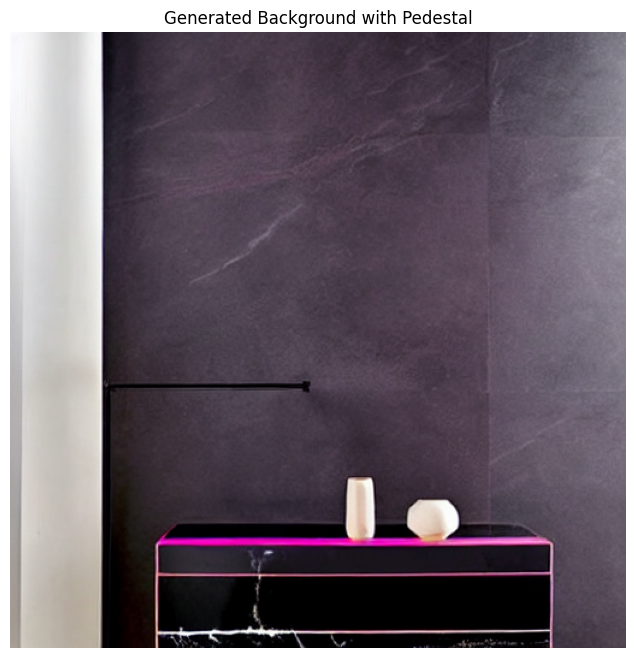

In [15]:
#F2
# ---------------- Install Required Packages ----------------
!pip install -U bitsandbytes transformers diffusers accelerate safetensors

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import gc

# ---------------- Model Name ----------------
model_name = 'filipealmeida/Mistral-7B-Instruct-v0.1-sharded'


# ---------------- Load Quantized Model ----------------
def load_quantized_model(model_name):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        llm_int8_enable_fp32_cpu_offload=True
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    return model


# ---------------- Initialize Tokenizer ----------------
def initialize_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.bos_token_id is None:
        tokenizer.bos_token_id = tokenizer.cls_token_id or 1
    if tokenizer.eos_token_id is None:
        tokenizer.eos_token_id = tokenizer.sep_token_id or 2
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer


# ---------------- Build Chat Prompt ----------------
def build_chat_prompt(user_text: str):
    return (
        "You are a meticulous ad-background generator. "
        "Follow ALL constraints exactly. "
        "Output only the 5-line background description.\n\n"
        f"{user_text}"
    )


# ---------------- Generate Response ----------------
def generate_response(prompt_text: str, model, tokenizer):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    chat_prompt = build_chat_prompt(prompt_text)

    inputs = tokenizer(chat_prompt, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

    torch.manual_seed(0)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            do_sample=True,
            temperature=0.7,
            max_new_tokens=200,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated_tokens = output[0][inputs['input_ids'].shape[1]:]
    text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return text


# ---------------- Enforce Exactly 5 Lines ----------------
def enforce_5_lines(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]

    if len(lines) == 1 and len(lines[0]) > 100:
        sentences = [s.strip() for s in lines[0].split('.') if s.strip()]
        lines = sentences

    if len(lines) < 5:
        new_lines = []
        for line in lines:
            if len(line) > 80 and ',' in line:
                parts = [part.strip() for part in line.split(',') if part.strip()]
                new_lines.extend(parts[:2])
            else:
                new_lines.append(line)
        lines = new_lines

    base_elements = [
        "Soft gradient transitions create depth and dimension",
        "Subtle lighting enhances the overall composition",
        "Abstract patterns add visual interest without distraction",
        "Professional photography aesthetic maintains focus",
        "Clean minimal design complements the product presentation"
    ]

    while len(lines) < 5:
        lines.append(base_elements[len(lines) - 1] if len(lines) - 1 < len(base_elements) else base_elements[-1])

    return lines[:5]


# ---------------- Pedestal Style Selector ----------------
def get_pedestal_style(data):
    subcat = str(data.get("subCategory", "")).lower()
    base_colour = str(data.get("baseColour", "")).lower()

    if "watch" in subcat:
        return "a sleek black marble pedestal with a glossy finish"
    elif "shoes" in subcat:
        return "a modern concrete pedestal with subtle texture"
    elif "bag" in subcat:
        return "a chic beige stone pedestal with smooth edges"
    elif "perfume" in subcat:
        return "a crystal glass pedestal reflecting soft light"
    elif "jewellery" in subcat or "jewelry" in subcat:
        return "a luxurious polished rose gold pedestal"
    else:
        return "a minimal matte white pedestal"


# ---------------- Build Product Prompt ----------------
def generate_prompt_for_ad_background(data, color, motif):
    description_parts = []

    for key, value in data.items():
        if value and str(value).strip():
            if key.lower() in ['gender']:
                description_parts.append(f"designed for {str(value).lower()}")
            elif key.lower() in ['basecolour', 'color', 'colour']:
                description_parts.append(f"features a {str(value).lower()} color scheme")
            elif key.lower() in ['usage', 'occasion']:
                description_parts.append(f"intended for {str(value).lower()} use")
            elif key.lower() in ['mastercategory', 'category']:
                description_parts.append(f"part of the {str(value).lower()} collection")
            elif key.lower() in ['subcategory', 'type']:
                description_parts.append(f"specifically a {str(value).lower()} item")
            elif key.lower() in ['year', 'season']:
                description_parts.append(f"from {str(value)}")
            else:
                description_parts.append(f"has {key.lower()} of {str(value).lower()}")

    if description_parts:
        product_description = "This product " + ", ".join(description_parts) + "."
    else:
        product_description = "This is a product that needs an advertising background."

    return f"""
Context:
{product_description}

Constraints (MUST follow exactly):
- Background color scheme should be based on {color} tones.
- Design motif should be inspired by {motif} but ONLY as abstract design elements.
- NO realistic objects, people, furniture, or interiors.
- NO literal representations of {motif} - only abstract interpretations.
- Must be a clean, professional advertising background that complements the product.
- Output EXACTLY 5 separate lines.

Output format (CRITICAL):
- Line 1: background color/gradient
- Line 2: abstract design elements
- Line 3: lighting and atmosphere
- Line 4: texture/surface qualities
- Line 5: overall mood
""".strip()


# ---------------- Convert 5-line text to SD-friendly prompt ----------------
def text_to_visual_prompt(lines, color, motif):
    base_elements = [
        f"{color} color scheme",
        "abstract background",
        "professional lighting",
        "minimalist design",
        "commercial photography style",
        "clean aesthetic"
    ]

    if "flower" in motif.lower():
        base_elements.append("subtle organic patterns")
    elif "geometric" in motif.lower():
        base_elements.append("geometric patterns")
    elif "wave" in motif.lower():
        base_elements.append("flowing curves")
    else:
        base_elements.append("abstract design elements")

    abstract_keywords = ['gradient', 'glow', 'shine', 'smooth', 'flowing', 'soft', 'subtle', 'elegant', 'refined']
    for line in lines:
        line_lower = line.lower()
        for keyword in abstract_keywords:
            if keyword in line_lower and keyword not in base_elements:
                base_elements.append(keyword)

    visual_prompt = ", ".join(base_elements[:8])
    return visual_prompt


# ---------------- Memory Cleanup Function ----------------
def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ---------------- Main Generation Function ----------------
def generate_ad_background_for_product(product_data, background_color, motif):
    print("=== Starting Ad Background Generation ===")
    print(f"Product Data: {product_data}")
    print(f"Background Color: {background_color}")
    print(f"Motif: {motif}")
    
    # Load Mistral
    print("Loading Mistral...")
    model = load_quantized_model(model_name)
    tokenizer = initialize_tokenizer(model_name)
    
    # Generate background description
    ad_prompt = generate_prompt_for_ad_background(product_data, background_color, motif)
    raw_output = generate_response(ad_prompt, model, tokenizer)
    ad_lines = enforce_5_lines(raw_output)
    
    print("Generated Background Description:")
    for i, line in enumerate(ad_lines, 1):
        print(f"{i}. {line}")
    
    # Build negative prompt
    excluded_terms = []
    for key, value in product_data.items():
        if key.lower() in ['subcategory', 'mastercategory', 'category', 'type'] and value:
            excluded_terms.append(str(value).lower())

    negative_prompt = "text, words, logo, watermark, signature, human, person, object, product, realistic, photorealistic, literal"
    if excluded_terms:
        negative_prompt += ", " + ", ".join(excluded_terms)

    if "flower" in motif.lower():
        negative_prompt += ", realistic flowers, petals, stems, leaves, garden, nature"
    elif "wave" in motif.lower():
        negative_prompt += ", ocean, water, sea, realistic waves"
    elif "star" in motif.lower():
        negative_prompt += ", realistic stars, night sky, space"

    # Convert background text to SD prompt
    background_prompt = text_to_visual_prompt(ad_lines, background_color, motif)
    pedestal = get_pedestal_style(product_data)

    sd_prompt = f"{pedestal}, {background_prompt}"
    print(f"\nStable Diffusion Prompt: {sd_prompt}")
    print(f"Negative Prompt: {negative_prompt}")

    # Free LLM memory
    model.cpu()
    del model
    cleanup_memory()

    # Load Stable Diffusion
    print("Loading Stable Diffusion pipeline...")
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")
    pipe.safety_checker = None

    # Generate image
    print("Generating background with pedestal...")
    background_image = pipe(
        prompt=sd_prompt,
        negative_prompt=negative_prompt,
        guidance_scale=8.0,
        num_inference_steps=50
    ).images[0]

    background_image.save("generated_background.png")
    print("Background + pedestal generated successfully!")

    plt.figure(figsize=(10, 8))
    plt.imshow(background_image)
    plt.axis("off")
    plt.title("Generated Background with Pedestal")
    plt.show()

    return background_image, ad_lines, sd_prompt


# ---------------- Example Usage ----------------
if __name__ == "__main__":
    product_data = {
        "gender": "women",
        "baseColour": "black",
        "usage": "casual",
        "subCategory": "watch",
        "masterCategory": "accessories",
        "year": 2016
    }

    generate_ad_background_for_product(
        product_data=product_data,
        background_color="blue",
        motif="white flowers"
    )


In [2]:
pip install -U peft


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 12.1 MB/s eta 0:00:0000:01
  Attempting uninstall: peft
    Found existing installation: peft 0.15.2
    Uninstalling peft-0.15.2:
      Successfully uninstalled peft-0.15.2
Note: you may need to restart the kernel to use updated packages.


=== Fully Automated Ad Background Generation ===
Product Data: {'gender': 'women', 'baseColour': 'smartphones', 'usage': 'casual', 'subCategory': 'phone'}
Auto-selected Background Color: neutral professional gradient
Auto-selected Motif: soft abstract pastel shapes
Pedestal: a minimal matte white pedestal
Background: a clean lifestyle background with soft daylight gradient
--------------------------------------------------
Generated Ad Background Description:
1. a minimal matte white pedestal
2. a clean lifestyle background with soft daylight gradient
3. Abstract soft abstract pastel shapes subtly integrated into the backdrop
4. Studio lighting highlights the pedestal edges and product focus
5. Professional luxury advertising mood with clean composition

Stable Diffusion Prompt: a minimal matte white pedestal, a clean lifestyle background with soft daylight gradient, soft abstract pastel shapes, professional product photography, clean composition, advertising style
Negative Prompt: tex

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating background image...


  0%|          | 0/50 [00:00<?, ?it/s]

Background generated successfully!


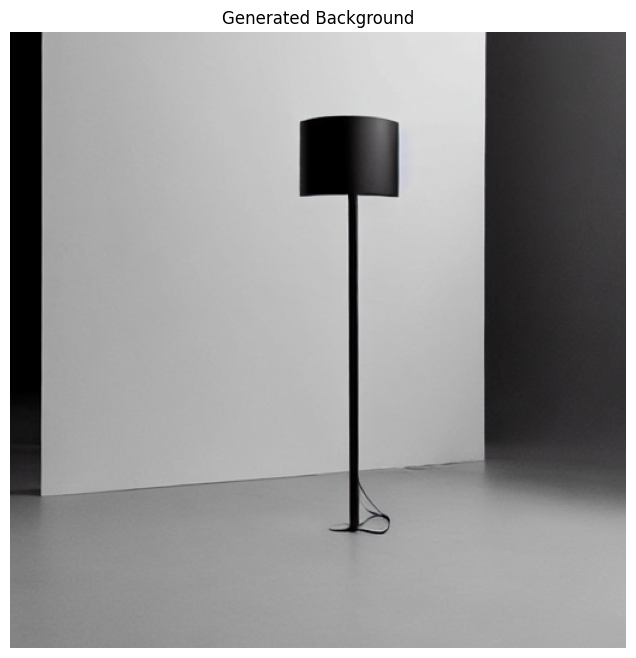

In [14]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt


# ---------------- Memory Cleanup Function ----------------
def get_automatic_styling(data):
    """
    Fallback auto-styling for background color + motif based on product metadata.
    """
    subcat = str(data.get("subCategory", "")).lower()
    usage = str(data.get("usage", "")).lower()
    base_colour = str(data.get("baseColour", "")).lower()

    # Background color heuristic
    if "silver" in base_colour:
        background_color = "cool grey tones"
    elif "gold" in base_colour:
        background_color = "warm golden tones"
    elif "black" in base_colour:
        background_color = "sleek dark tones"
    elif "white" in base_colour:
        background_color = "minimal soft white"
    else:
        background_color = "neutral professional gradient"

    # Motif heuristic
    if "perfume" in subcat:
        motif = "delicate floral swirls"
    elif "watch" in subcat:
        motif = "subtle radial clock-inspired lines"
    elif "shoes" in subcat:
        motif = "dynamic motion streaks"
    elif "bag" in subcat:
        motif = "elegant geometric accents"
    elif "jewellery" in subcat or "jewelry" in subcat:
        motif = "sparkling crystal highlights"
    elif "casual" in usage:
        motif = "soft abstract pastel shapes"
    elif "formal" in usage:
        motif = "clean linear gradients"
    else:
        motif = "minimal abstract texture"

    return background_color, motif


# ---------------- Pedestal Style Selector ----------------
def get_pedestal_style(data):
    subcat = str(data.get("subCategory", "")).lower()
    base_colour = str(data.get("baseColour", "")).lower()

    if "watch" in subcat:
        return "a sleek black marble pedestal with a glossy finish"
    elif "shoes" in subcat:
        return "a modern concrete pedestal with subtle texture"
    elif "bag" in subcat:
        return "a chic beige stone pedestal with smooth edges"
    elif "perfume" in subcat:
        return "a crystal glass pedestal reflecting soft light"
    elif "jewellery" in subcat or "jewelry" in subcat:
        return "a luxurious polished rose gold pedestal"
    else:
        return "a minimal matte white pedestal"


# ---------------- Background Style Selector ----------------
def get_background_style(data):
    usage = str(data.get("usage", "")).lower()
    subcat = str(data.get("subCategory", "")).lower()
    base_colour = str(data.get("baseColour", "")).lower()

    if "perfume" in subcat:
        return "a soft blurred floral background with pastel tones"
    elif "watch" in subcat:
        return "a modern gradient grey studio backdrop with soft spotlight"
    elif "shoes" in subcat:
        return "an elegant wooden floor fade with neutral studio wall"
    elif "bag" in subcat:
        return "a chic beige-toned background with subtle shadow play"
    elif "jewellery" in subcat or "jewelry" in subcat:
        return "a luxurious velvet background with soft golden bokeh"
    elif "casual" in usage:
        return "a clean lifestyle background with soft daylight gradient"
    elif "formal" in usage:
        return "a premium dark gradient with subtle rim lighting"
    else:
        return "a professional clean studio setup with neutral tones"


# ---------------- Combined Automatic Prompt Generator ----------------
def generate_ad_background_automatic(product_data):
    print("=== Fully Automated Ad Background Generation ===")
    print(f"Product Data: {product_data}")

    # Auto-styling
    background_color, motif = get_automatic_styling(product_data)
    pedestal = get_pedestal_style(product_data)
    background = get_background_style(product_data)

    print(f"Auto-selected Background Color: {background_color}")
    print(f"Auto-selected Motif: {motif}")
    print(f"Pedestal: {pedestal}")
    print(f"Background: {background}")
    print("-" * 50)

    # Generate 5-line description
    ad_lines = [
        pedestal,
        background,
        f"Abstract {motif} subtly integrated into the backdrop",
        "Studio lighting highlights the pedestal edges and product focus",
        "Professional luxury advertising mood with clean composition"
    ]

    print("Generated Ad Background Description:")
    for i, line in enumerate(ad_lines, 1):
        print(f"{i}. {line}")

    # Negative prompt
    negative_prompt = (
        "text, words, logo, watermark, human, person, face, hands, "
        "cups, bottles, books, clothes, gadgets, plants, flowers, clutter, "
        "any other objects on pedestal or background"
    )

    # Stable Diffusion prompt
    sd_prompt = (
        f"{pedestal}, {background}, {motif}, "
        "professional product photography, clean composition, advertising style"
    )

    print(f"\nStable Diffusion Prompt: {sd_prompt}")
    print(f"Negative Prompt: {negative_prompt}")

    # Load Stable Diffusion
    print("Loading Stable Diffusion pipeline...")
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")
    pipe.safety_checker = None

    # Generate image
    print("Generating background image...")
    background_image = pipe(
        prompt=sd_prompt,
        negative_prompt=negative_prompt,
        guidance_scale=8.0,
        num_inference_steps=50
    ).images[0]

    background_image.save("generated_background.png")
    print("Background generated successfully!")

    plt.figure(figsize=(10, 8))
    plt.imshow(background_image)
    plt.axis("off")
    plt.title("Generated Background")
    plt.show()

    return background_image, ad_lines, sd_prompt


# ---------------- Example Run ----------------
if __name__ == "__main__":
    product_data = {
        "gender": "women",
        "baseColour": "smartphones",
        "usage": "casual",
        "subCategory": "phone"
    }
    generate_ad_background_automatic(product_data)


# Testing the output

In [9]:
if __name__ == "__main__":
    product_data = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watch"
    }

    background_image, ad_lines, sd_prompt = generate_ad_background_automatic(product_data)


=== Fully Automated Ad Background Generation ===
Product Data: {'gender': 'women', 'baseColour': 'silver', 'usage': 'casual', 'subCategory': 'watch'}


NameError: name 'get_automatic_styling' is not defined

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Generating image with Stable Diffusion...


  0%|          | 0/40 [00:00<?, ?it/s]

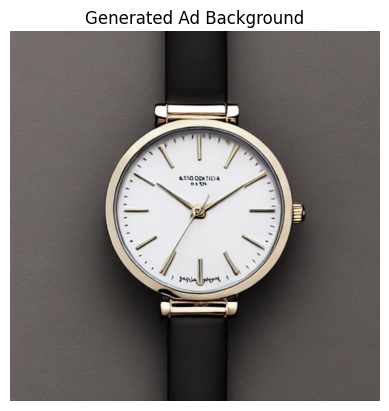


=== STABLE DIFFUSION PROMPT USED ===
A professional product photo of a silver watch for women, placed on a sleek metallic pedestal with soft spotlight, against a luxurious dark gradient background with glowing edges. Studio lighting, highly detailed, aesthetic composition.


In [11]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt


def get_pedestal_style(data):
    subcat = data.get("subCategory", "").lower()

    if "watch" in subcat:
        return "sleek metallic pedestal with soft spotlight"
    elif "shoes" in subcat:
        return "matte stone pedestal with subtle floor reflection"
    elif "bag" in subcat:
        return "modern acrylic pedestal with elegant shadowing"
    elif "perfume" in subcat:
        return "luxury marble pedestal with glossy highlights"
    else:
        return "minimal neutral-toned pedestal"


def get_background_style(data):
    usage = data.get("usage", "").lower()
    subcat = data.get("subCategory", "").lower()

    if "watch" in subcat:
        return "luxurious dark gradient background with glowing edges"
    elif "shoes" in subcat:
        return "urban textured backdrop with soft lighting"
    elif "bag" in subcat:
        return "stylish studio background with muted beige tones"
    elif "perfume" in subcat:
        return "aesthetic blurred floral background with warm bokeh lights"
    else:
        return "clean minimal background with smooth gradients"


def generate_ad_background_automatic(product_data, pipe):
    # Choose pedestal + background
    pedestal = get_pedestal_style(product_data)
    background = get_background_style(product_data)

    # Combine into Stable Diffusion prompt
    sd_prompt = (
        f"A professional product photo of a {product_data.get('baseColour', '')} "
        f"{product_data.get('subCategory', '')} for {product_data.get('gender', '')}, "
        f"placed on a {pedestal}, against a {background}. "
        f"Studio lighting, highly detailed, aesthetic composition."
    )

    # Generate image
    print("Generating image with Stable Diffusion...")
    image = pipe(
        prompt=sd_prompt,
        negative_prompt="text, logo, watermark, human, hands, clutter",
        guidance_scale=8.0,
        num_inference_steps=40
    ).images[0]

    # Save + show
    image.save("generated_ad.png")
    plt.imshow(image)
    plt.axis("off")
    plt.title("Generated Ad Background")
    plt.show()

    return image, sd_prompt


def int_main():
    # Load SD pipeline once
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")
    pipe.safety_checker = None  # disable NSFW filter if needed

    # Example product
    product_data_1 = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watch"
    }

    image, sd_prompt = generate_ad_background_automatic(product_data_1, pipe)

    print("\n=== STABLE DIFFUSION PROMPT USED ===")
    print(sd_prompt)


if __name__ == "__main__":
    int_main()


In [8]:
if __name__ == "__main__":
    # Example 1: Fully Automated - Women's Silver Watch
    print("=== FULLY AUTOMATED EXAMPLES ===")
    print("")
    product_data_1 = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watches",
        "masterCategory": "accessories",
        "year": 2016
    }

    # Just call with product data - everything else is automatic!
    generate_ad_background_automatic(product_data_1)

    # Example 2: Men's Black Formal Shoes - Fully Automated
    print("\n" + "="*60)
    print("Example 2: Men's Formal Shoes - Fully Automated")

    product_data_2 = {
        "gender": "men",
        "baseColour": "black",
        "usage": "formal",
        "subCategory": "shoes",
        "masterCategory": "footwear",
        "year": 2023
    }

    generate_ad_background_automatic(product_data_2)

    # Example 3: Women's Gold Jewelry - Fully Automated
    print("\n" + "="*60)
    print("Example 3: Women's Gold Jewelry - Fully Automated")

    product_data_3 = {
        "gender": "women",
        "baseColour": "gold",
        "usage": "party",
        "subCategory": "necklaces",
        "masterCategory": "jewelry",
        "year": 2024
    }

    generate_ad_background_automatic(product_data_3)

    # Example 4: Men's Tech Product - Fully Automated
    print("\n" + "="*60)
    print("Example 4: Men's Electronics - Fully Automated")

    product_data_4 = {
        "gender": "men",
        "baseColour": "blue",
        "usage": "everyday",
        "subCategory": "smartphones",
        "masterCategory": "electronics",
        "year": 2024
    }

    generate_ad_background_automatic(product_data_4)

    print("\n" + "="*60)
    print("MANUAL MODE STILL AVAILABLE:")
    print("You can still use generate_ad_background_for_product() for manual control")


=== FULLY AUTOMATED EXAMPLES ===

=== Fully Automated Ad Background Generation ===
Product Data: {'gender': 'women', 'baseColour': 'silver', 'usage': 'casual', 'subCategory': 'watches', 'masterCategory': 'accessories', 'year': 2016}


NameError: name 'get_automatic_styling' is not defined

# Trying different style pedestal


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

=== FULLY AUTOMATED EXAMPLES WITH PEDESTAL ===


  0%|          | 0/40 [00:00<?, ?it/s]

✅ Ad background with pedestal generated and displayed
Prompt used: Professional product advertisement background for a women's silver watches. minimalistic gradient with soft spotlight. A a small elegant circular marble pedestal is placed at the center-bottom, with clean lighting, and empty space above for the product.


Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmphvbytola.PNG'


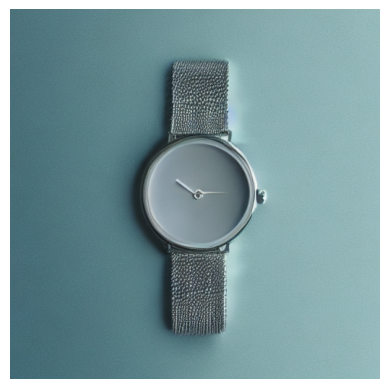

  0%|          | 0/40 [00:00<?, ?it/s]

✅ Ad background with pedestal generated and displayed
Prompt used: Professional product advertisement background for a men's black shoes. modern studio background with clean floor texture. A a medium matte black square pedestal is placed at the center-bottom, with clean lighting, and empty space above for the product.


Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmpsk5fxbt_.PNG'


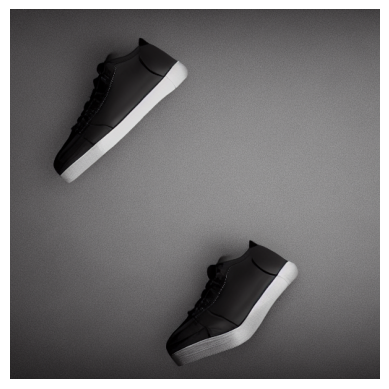

  0%|          | 0/40 [00:00<?, ?it/s]

✅ Ad background with pedestal generated and displayed
Prompt used: Professional product advertisement background for a women's gold necklaces. luxurious velvet drape with warm lighting. A a small elegant circular marble pedestal is placed at the center-bottom, with clean lighting, and empty space above for the product.


Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmpxh4n92v8.PNG'


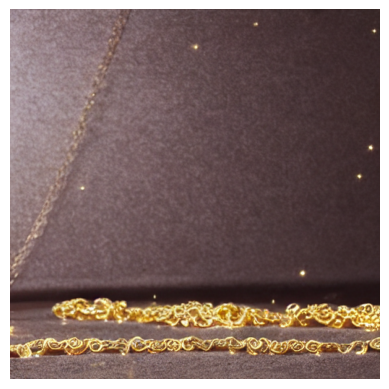

  0%|          | 0/40 [00:00<?, ?it/s]

✅ Ad background with pedestal generated and displayed
Prompt used: Professional product advertisement background for a men's blue smartphones. futuristic neon tech environment. A a wide metallic pedestal with soft glow is placed at the center-bottom, with clean lighting, and empty space above for the product.


Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening '/tmp/tmp38ctlyxi.PNG'


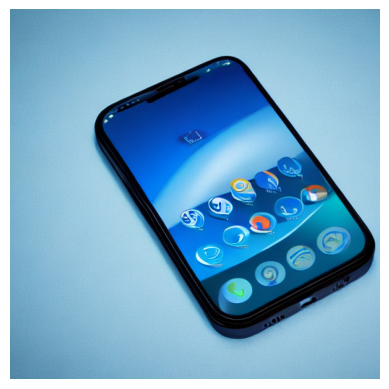


Manual mode still available: use generate_ad_background_for_product() if you want custom control.


In [13]:
from diffusers import StableDiffusionPipeline
import torch

# load diffusion pipeline once
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)

def generate_ad_background_automatic_with_pedestal(product_data):
    """
    Generate and display an advertisement background image with a pedestal for product placement.
    """

    gender = product_data.get("gender", "")
    colour = product_data.get("baseColour", "")
    usage = product_data.get("usage", "")
    sub = product_data.get("subCategory", "")
    master = product_data.get("masterCategory", "")

    # background selection
    themes = {
        "jewelry": "luxurious velvet drape with warm lighting",
        "watches": "minimalistic gradient with soft spotlight",
        "shoes": "modern studio background with clean floor texture",
        "electronics": "futuristic neon tech environment",
        "default": "neutral gradient background with soft shadows"
    }
    theme = themes.get(sub, themes.get(master, themes["default"]))

    # pedestal prompt
    if sub in ["watches", "jewelry", "necklaces"]:
        pedestal = "a small elegant circular marble pedestal"
    elif sub in ["shoes"]:
        pedestal = "a medium matte black square pedestal"
    elif sub in ["smartphones", "electronics"]:
        pedestal = "a wide metallic pedestal with soft glow"
    else:
        pedestal = "a stylish acrylic pedestal"

    # build prompt
    prompt = (
        f"Professional product advertisement background for a {gender}'s {colour} {sub}. "
        f"{theme}. "
        f"A {pedestal} is placed at the center-bottom, with clean lighting, "
        f"and empty space above for the product."
    )

    # generate image
    image = pipe(prompt, guidance_scale=7.5, num_inference_steps=40).images[0]

    # display instead of saving
    image.show()   # opens in system viewer / displays inline in notebooks

    print("✅ Ad background with pedestal generated and displayed")
    print(f"Prompt used: {prompt}")
    return image


# ================== MAIN EXECUTION ==================
import matplotlib.pyplot as plt
from PIL import Image

# ================== MAIN EXECUTION ==================
if __name__ == "__main__":
    print("=== FULLY AUTOMATED EXAMPLES WITH PEDESTAL ===")

    def show_image_inline(img):
        plt.imshow(img)
        plt.axis("off")
        plt.show()

    # Example 1: Women's Silver Watch
    product_data_1 = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watches",
        "masterCategory": "accessories",
        "year": 2016
    }
    img1 = generate_ad_background_automatic_with_pedestal(product_data_1)
    show_image_inline(img1)

    # Example 2: Men's Black Formal Shoes
    print("\n" + "="*60)
    product_data_2 = {
        "gender": "men",
        "baseColour": "black",
        "usage": "formal",
        "subCategory": "shoes",
        "masterCategory": "footwear",
        "year": 2023
    }
    img2 = generate_ad_background_automatic_with_pedestal(product_data_2)
    show_image_inline(img2)

    # Example 3: Women's Gold Jewelry
    print("\n" + "="*60)
    product_data_3 = {
        "gender": "women",
        "baseColour": "gold",
        "usage": "party",
        "subCategory": "necklaces",
        "masterCategory": "jewelry",
        "year": 2024
    }
    img3 = generate_ad_background_automatic_with_pedestal(product_data_3)
    show_image_inline(img3)

    # Example 4: Men's Smartphone
    print("\n" + "="*60)
    product_data_4 = {
        "gender": "men",
        "baseColour": "blue",
        "usage": "everyday",
        "subCategory": "smartphones",
        "masterCategory": "electronics",
        "year": 2024
    }
    img4 = generate_ad_background_automatic_with_pedestal(product_data_4)
    show_image_inline(img4)

    print("\n" + "="*60)
    print("Manual mode still available: use generate_ad_background_for_product() if you want custom control.")


In [15]:
if __name__ == "__main__":
    print("=== FULLY AUTOMATED EXAMPLES WITH PEDESTAL ===")

    # Example 1: Women's Silver Watch
    product_data_1 = {
        "gender": "women",
        "baseColour": "silver",
        "usage": "casual",
        "subCategory": "watches",
        "masterCategory": "accessories",
        "year": 2016
    }
    generate_ad_background_automatic_with_pedestal(product_data_1, "watch_with_pedestal.png")

    # Example 2: Men's Black Formal Shoes
    print("\n" + "="*60)
    product_data_2 = {
        "gender": "men",
        "baseColour": "black",
        "usage": "formal",
        "subCategory": "shoes",
        "masterCategory": "footwear",
        "year": 2023
    }
    generate_ad_background_automatic_with_pedestal(product_data_2, "shoes_with_pedestal.png")

    # Example 3: Women's Gold Jewelry
    print("\n" + "="*60)
    product_data_3 = {
        "gender": "women",
        "baseColour": "gold",
        "usage": "party",
        "subCategory": "necklaces",
        "masterCategory": "jewelry",
        "year": 2024
    }
    generate_ad_background_automatic_with_pedestal(product_data_3, "jewelry_with_pedestal.png")

    # Example 4: Men's Smartphone
    print("\n" + "="*60)
    product_data_4 = {
        "gender": "men",
        "baseColour": "blue",
        "usage": "everyday",
        "subCategory": "smartphones",
        "masterCategory": "electronics",
        "year": 2024
    }
    generate_ad_background_automatic_with_pedestal(product_data_4, "smartphone_with_pedestal.png")

    print("\n" + "="*60)
    print("Manual mode still available: use generate_ad_background_for_product() if you want custom control.")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

# Prev

In [ ]:
#prev ones give it to me : only then
#previous codes are similar to the current ones

=== Starting 3D Pedestal Generation ===
Product Data: {'gender': 'men', 'baseColour': 'blue', 'usage': 'everyday', 'subCategory': 'smartphones', 'masterCategory': 'electronics', 'year': 2024}
Background Color: elegant white blue
Motif: soft gradients, clean circles, subtle abstract shapes

Stable Diffusion Prompt: professional product photography, realistic 3D modern blue pedestal with elegant texture in center, photorealistic rendering, studio lighting, clean shadows, elegant white blue gradient background, depth of field, high quality 3D render, product display setup, empty pedestal surface, professional commercial photography, realistic materials
Pedestal Selected: modern blue pedestal with elegant texture


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

3D Pedestal generated successfully!


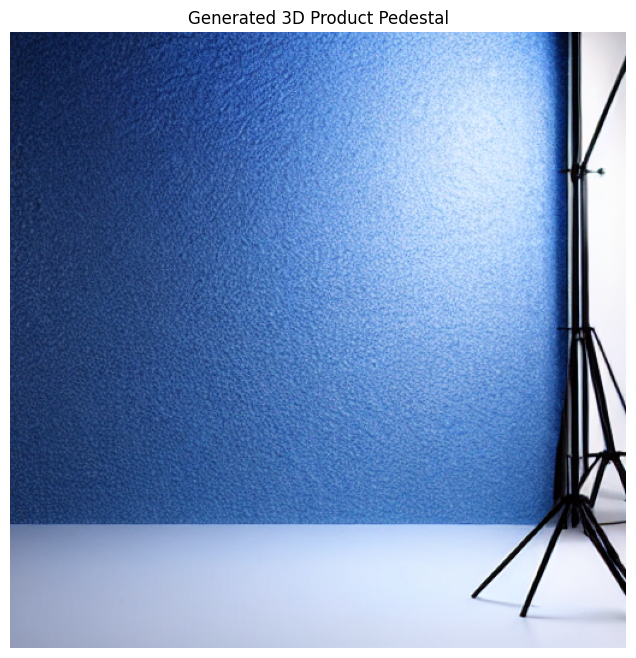

In [4]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# -------------------------------
# Utility: choose pedestal style
# -------------------------------
def get_pedestal_style(data):
    """
    Decide pedestal style based on product metadata.
    """
    gender = data.get("gender", "").lower()
    subcat = data.get("subCategory", "").lower()
    base_colour = data.get("baseColour", "").lower()

    if "watch" in subcat:
        return "sleek metallic pedestal with a glossy finish"
    elif "shoe" in subcat or "sneaker" in subcat:
        return "minimal white marble pedestal"
    elif "bag" in subcat:
        return "luxury velvet pedestal"
    else:
        return f"modern {base_colour} pedestal with elegant texture"


# -------------------------------
# Build pedestal prompt
# -------------------------------
def text_to_visual_prompt_with_pedestal(lines, color, motif, pedestal):
    """
    Creates a proper 3D pedestal prompt for Stable Diffusion
    """
    if "circular" in pedestal.lower():
        pedestal_type = "cylindrical white pedestal"
    elif "square" in pedestal.lower():
        pedestal_type = "cubic white pedestal"
    else:
        pedestal_type = "white pedestal platform"

    prompt_parts = [
        f"professional product photography setup",
        f"3D {pedestal_type} in center",
        f"realistic pedestal with depth and shadows",
        f"{color} gradient background",
        f"studio lighting on pedestal",
        f"clean minimalist composition",
        f"product display stand",
        f"photorealistic 3D rendering"
    ]

    if "flower" in motif.lower():
        prompt_parts.append("subtle floral patterns in background")
    elif "geometric" in motif.lower():
        prompt_parts.append("geometric patterns in background")
    elif "wave" in motif.lower():
        prompt_parts.append("flowing wave patterns in background")
    else:
        prompt_parts.append("abstract design elements in background")

    return ", ".join(prompt_parts)


# -------------------------------
# Generate ad background with pedestal
# -------------------------------
def generate_ad_background_with_pedestal(product_data, background_color, motif):
    """
    Main function that generates background with realistic 3D pedestal
    """
    print("=== Starting 3D Pedestal Generation ===")
    print(f"Product Data: {product_data}")
    print(f"Background Color: {background_color}")
    print(f"Motif: {motif}")

    # Get pedestal info
    pedestal = get_pedestal_style(product_data)

    # Build Stable Diffusion prompt
    sd_prompt = (
        f"professional product photography, realistic 3D {pedestal} in center, "
        f"photorealistic rendering, studio lighting, clean shadows, "
        f"{background_color} gradient background, depth of field, "
        f"high quality 3D render, product display setup, empty pedestal surface, "
        f"professional commercial photography, realistic materials"
    )

    negative_prompt = (
        "flat design, 2D, cartoon, illustration, drawing, sketch, painting, "
        "low quality, blurry, distorted, deformed, ugly, bad anatomy, "
        "text, letters, words, logo, watermark, signature, "
        "objects on pedestal, products on stand, items on platform, "
        "people, humans, faces, hands, animals, "
        "cluttered, busy, messy, chaotic, "
        "unrealistic lighting, harsh shadows, overexposed"
    )

    print(f"\nStable Diffusion Prompt: {sd_prompt}")
    print(f"Pedestal Selected: {pedestal}")

    # Load Stable Diffusion
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16
    ).to("cuda")

    pipe.safety_checker = None

    # Generate background
    background_image = pipe(
        prompt=sd_prompt,
        negative_prompt=negative_prompt,
        guidance_scale=12.0,
        num_inference_steps=50,
        height=512,
        width=512,
        generator=torch.manual_seed(42)
    ).images[0]

    background_image.save("realistic_3d_pedestal.png")
    print("3D Pedestal generated successfully!")

    plt.figure(figsize=(10, 8))
    plt.imshow(background_image)
    plt.axis("off")
    plt.title("Generated 3D Product Pedestal")
    plt.show()

    return background_image, sd_prompt


# -------------------------------
# Usage Example
# -------------------------------
if __name__ == "__main__":
    product_data_4 = {
        "gender": "men",
        "baseColour": "blue",
        "usage": "everyday",
        "subCategory": "smartphones",
        "masterCategory": "electronics",
        "year": 2024
    }

    generate_ad_background_with_pedestal(
        product_data=product_data_4,
        background_color="elegant white blue",
        motif="soft gradients, clean circles, subtle abstract shapes"
    )


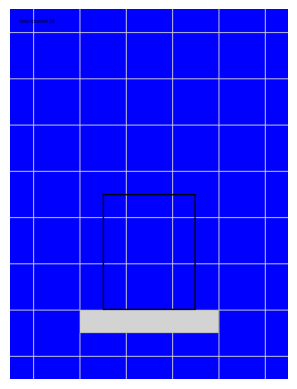

In [5]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

def generate_ad_background_with_pedestal(product_data, bg_prompt="clean white background with geometric motif"):
    """
    Generate a simple ad background with pedestal for a product.
    This does not use Stable Diffusion, only Pillow for now.
    """
    # Background color (choose from product data if not specified)
    bg_color = "white"
    if "baseColour" in product_data:
        if product_data["baseColour"].lower() in ["blue", "silver", "black"]:
            bg_color = product_data["baseColour"].lower()

    # Create blank background
    img = Image.new("RGB", (600, 800), bg_color)
    draw = ImageDraw.Draw(img)

    # Add motif based on prompt
    if "geometric" in bg_prompt.lower():
        for i in range(50, 600, 100):
            draw.line((i, 0, i, 800), fill="lightgray", width=2)
        for j in range(50, 800, 100):
            draw.line((0, j, 600, j), fill="lightgray", width=2)

    elif "gradient" in bg_prompt.lower():
        for y in range(800):
            shade = int(255 * (y / 800))
            draw.line((0, y, 600, y), fill=(shade, shade, 255))

    elif "abstract" in bg_prompt.lower():
        draw.ellipse((100, 100, 500, 400), fill="lightblue", outline="blue")
        draw.ellipse((150, 300, 450, 650), fill="lightgreen", outline="green")

    # Add pedestal
    pedestal_color = "lightgray"
    draw.rectangle((150, 650, 450, 700), fill=pedestal_color, outline="gray")

    # Add product placeholder (for now a rectangle where smartphone would go)
    draw.rectangle((200, 400, 400, 650), outline="black", width=3)

    # Add title text
    if "subCategory" in product_data:
        title = product_data["subCategory"].capitalize()
    else:
        title = "Product"

    font = None
    try:
        font = ImageFont.truetype("arial.ttf", 28)
    except:
        font = ImageFont.load_default()

    draw.text((20, 20), f"{title} Ad", fill="black", font=font)

    return img


# -------------------
# Example product data
# -------------------
product_data_4 = {
    "gender": "men",
    "baseColour": "blue",
    "usage": "everyday",
    "subCategory": "smartphones",
    "masterCategory": "electronics",
    "year": 2024
}

# Generate background with pedestal
bg_img = generate_ad_background_with_pedestal(product_data_4, bg_prompt="modern gradient background with geometric motif")

# Show in Kaggle notebook
plt.imshow(bg_img)
plt.axis("off")
plt.show()


In [6]:
def generate_elegant_pedestal_and_bg(obj_bbox):
    # Step 1: Compute pedestal size (tight fit + scale factor)
    bbox_dims = obj_bbox.max - obj_bbox.min
    pedestal_radius = max(bbox_dims[:2]) * 0.65
    pedestal_height = bbox_dims[2] * 0.01 
    pedestral_width = bbox_dims[1] * 0.05
    #if pedestral dimensions are defined then becomes generic for each product

    # Step 2: Create pedestal (multi-layer cylinder)
    base = trimesh.creation.cylinder(radius=pedestal_radius*1.2, height=pedestal_height)
    top = trimesh.creation.cylinder(radius=pedestal_radius, height=pedestal_height*0.8)
    pedestal = trimesh.util.concatenate([base, top])

    # Step 3: Background (gradient plane or sphere)
    background = create_gradient_sphere(color1=[240,240,245], color2=[200,220,255])

    return pedestal, background
